# AIS & Weather Data Processing


## 1. Setup

In [1]:
!pip install -q geopandas shapely


In [2]:
import os
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import NearestNDInterpolator

import ipywidgets as widgets
from IPython.display import display, clear_output
import plotly.express as px
import plotly.graph_objects as go

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-muted")

from google.colab import drive
print("Mounting Google Drive...")
drive.mount('/content/drive')


Mounting Google Drive...
Mounted at /content/drive


## Load the raw data

In [3]:
file_path = "/content/drive/MyDrive/LCO2 Transport Project Final/uncleaned_ais_copernicus_merged_dataset_2025.csv"
df = pd.read_csv(file_path)
df.head()


,BaseDateTime,LON,LAT,SOG,COG,Heading,IMO,Status,Length,Width,...,Cargo,drift_angle,z,depth,uo,vo,thetao,swh,mwd,wind_wave_height
0,2025-01-01 00:00:04,-90.29858,29.95597,14.3,40.7,41.0,IMO7816551,0.0,192.0,32.0,...,80.0,0.3,0,0.494025,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-01 00:00:03,-89.41682,29.35364,13.1,125.7,128.0,IMO9885908,0.0,229.0,35.0,...,80.0,2.3,1,0.494025,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-01-01 00:00:02,-95.20078,29.74000,4.6,52.9,54.0,IMO9724611,0.0,182.0,32.0,...,80.0,1.1,2,0.494025,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-01-01 00:00:07,-91.00400,30.16538,10.6,338.0,335.0,IMO9675078,0.0,147.0,23.0,...,81.0,-3.0,3,0.494025,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-01-01 00:00:04,-95.80819,27.19427,11.6,114.9,116.0,IMO9681857,0.0,183.0,32.0,...,80.0,1.1,4,0.494025,-0.043143,-0.134023,24.470795,1.21,77.290002,0.84


In [4]:
df.shape

(365318, 21)

In [5]:
df.columns

Index(['BaseDateTime', 'LON', 'LAT', 'SOG', 'COG', 'Heading', 'IMO', 'Status',
       'Length', 'Width', 'Draft', 'Cargo', 'drift_angle', 'z', 'depth', 'uo',
       'vo', 'thetao', 'swh', 'mwd', 'wind_wave_height'],
      dtype='object')

In [6]:
df.isnull().sum()

,0
BaseDateTime,0
LON,0
LAT,0
SOG,0
COG,0
Heading,0
IMO,0
Status,81
Length,0
Width,0


## Missing weather data by ship


In [7]:
ships_null = df.groupby("IMO").agg(
    total_pings=("BaseDateTime", "count"),
    null_pings=("uo", lambda x: x.isnull().sum()),
).reset_index()
ships_null["null_percentage"] = (ships_null["null_pings"] / ships_null["total_pings"]) * 100
ships_null = ships_null.sort_values("null_percentage", ascending=False)

completely_null = (ships_null["null_percentage"] == 100).sum()
total_ships = len(ships_null)

print(f"Total ships: {total_ships}")
print(f"Ships with completely missing weather data: {completely_null}")
print(f"Ships with at least some missing data: {(ships_null['null_percentage'] > 0).sum()}")
print(f"Ships with no missing data : {total_ships-((ships_null['null_percentage'] > 0).sum())}")
ships_null.head(10)


Total ships: 1720
Ships with completely missing weather data: 1
Ships with at least some missing data: 1645
Ships with no missing data : 75


,IMO,total_pings,null_pings,null_percentage
479,IMO9520869,3,3,100.000000
1086,IMO9804930,30,26,86.666667
219,IMO9379208,28,24,85.714286
264,IMO9392236,19,16,84.210526
1293,IMO9873668,30,25,83.333333
1028,IMO9793272,52,40,76.923077
1590,IMO9946702,41,31,75.609756
1585,IMO9945796,42,30,71.428571
1226,IMO9853228,47,33,70.212766
138,IMO9332494,43,30,69.767442


Ship Distribution by Missing Data
null_range
0-10%      504
10-20%     515
20-30%     355
30-40%     184
40-50%      93
50-60%      39
60-70%      21
70-80%       4
80-90%       4
90-100%      1
Name: count, dtype: int64


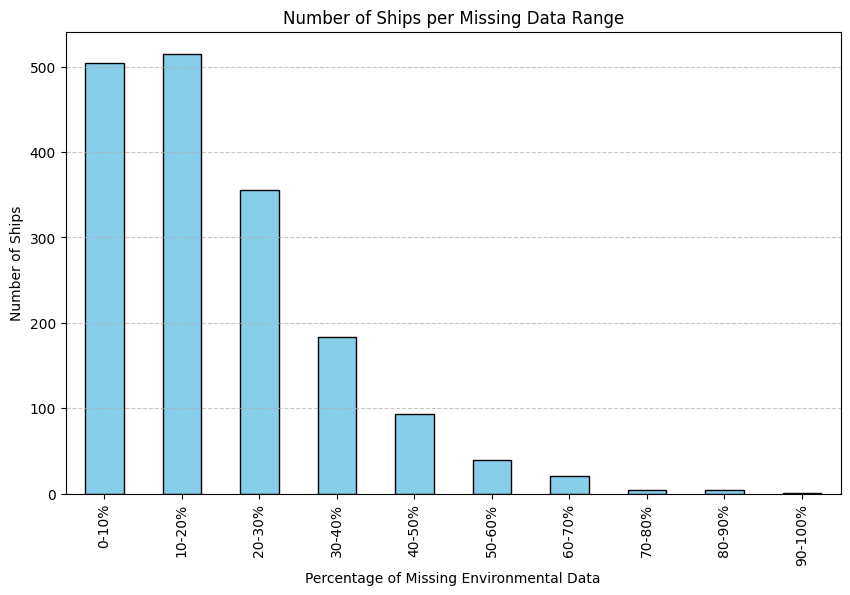

In [8]:
#  Categorize ships
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
labels = ['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%', '80-90%', '90-100%']

ships_null['null_range'] = pd.cut(ships_null['null_percentage'], bins=bins, labels=labels, include_lowest=True)

range_counts = ships_null['null_range'].value_counts().sort_index()

print("Ship Distribution by Missing Data")
print(range_counts)

#  Visualize
plt.figure(figsize=(10, 6))
range_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Number of Ships per Missing Data Range')
plt.xlabel('Percentage of Missing Environmental Data')
plt.ylabel('Number of Ships')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [9]:
!pip install geoviews cartopy holoviews jupyter_bokeh hvplot bokeh --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 574.7/574.7 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.6/180.6 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 42.8 MB/s eta 0:00:00


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
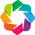

:HoloMap   [Vessel MMSI]
   :Overlay
      .WMTS.I          :WMTS   [Longitude,Latitude]
      .Points.I        :Points   [Longitude,Latitude]   (IMO_STR,SOG,Draft,BaseDateTime)
      .Points.CCS_Hubs :Points   [lon,lat]   (name)
      .Labels.I        :Labels   [lon,lat]   (name)

In [10]:
import geopandas as gpd
import holoviews as hv
import geoviews as gv
from holoviews import opts
from cartopy import crs

hv.extension('bokeh')

hub_data = pd.DataFrame([
    {'name': 'Bayou Bend', 'lat': 29.6000, 'lon': -94.0000}, {'name': 'Houston Ship Channel', 'lat': 29.35, 'lon': -94.77}, {'name': 'Port Arthur', 'lat': 29.893, 'lon': -93.938},
    {'name': 'Plaquemine Corridor', 'lat': 30.289, 'lon': -91.221}, {'name': 'ExxonMobil / Denbury Lease', 'lat': 29.461, 'lon': -94.197}, {'name': 'Repsol Offshore North 1', 'lat': 27.846, 'lon': -97.025}
])
search_buffer = 0.60

ships_to_plot = ships_null[ships_null['null_range'] == '90-100%'].sort_values(
    by='null_percentage', ascending=False
).head(10)
top_10_mmsis = ships_to_plot['IMO'].tolist()
df_plot = df[df['IMO'].isin(top_10_mmsis)].sort_values(['IMO', 'BaseDateTime'])

# Geodataframe
gdf_plot = gpd.GeoDataFrame(df_plot, geometry=gpd.points_from_xy(df_plot.LON, df_plot.LAT), crs="EPSG:4326")
gdf_plot['IMO_STR'] = gdf_plot['IMO'].astype(str)

hub_points = gv.Points(hub_data, kdims=['lon', 'lat'], label='CCS Hubs').opts(
    size=12, color='red', marker='triangle', line_color='black', tools=['hover']
)

hub_labels = gv.Labels(hub_data, kdims=['lon', 'lat'], vdims='name').opts(
    text_font_size='12pt', text_color='red', text_font_style='bold', xoffset=0.2
)

# Selection
def select_ship_with_hubs(mmsi_selection):
    vessel_data = gdf_plot[gdf_plot['IMO_STR'] == mmsi_selection]

    vessel_points = gv.Points(vessel_data, vdims=['IMO_STR', 'SOG', 'Draft', 'BaseDateTime'],
                              crs=crs.PlateCarree())

    return gv.tile_sources.OSM * vessel_points.opts(
        opts.Points(color='SOG', cmap='plasma', size=6, alpha=0.8,
                    tools=['hover'], width=850, height=600, colorbar=True)
    ) * hub_points * hub_labels

ship_list = sorted(gdf_plot['IMO_STR'].unique())
interactive_map = hv.HoloMap({m: select_ship_with_hubs(m) for m in ship_list}, kdims='Vessel MMSI')

interactive_map

In [11]:
# Define bounding box coordinates
lat_min, lat_max = 26, 32
lon_min, lon_max = -100, -85

# a mask to filter coordinates
mask = (df['LAT'].between(lat_min, lat_max)) & \
       (df['LON'].between(lon_min, lon_max))

unique_ships = df[mask]['IMO'].nunique()
total_rows = mask.sum()

print(f"Total rows (pings) in the region: {total_rows}")
print(f"Total unique ships in the region: {unique_ships}")
print(f"total length of df {len(df)}")
print(f"percent of dataset that is in the region {total_rows/len(df)*100}")

Total rows (pings) in the region: 365318
Total unique ships in the region: 1720
total length of df 365318
percent of dataset that is in the region 100.0


In [12]:
df_region = df[mask]

top_15_mmsis = df_region['IMO'].value_counts().head(15).index.tolist()  #  MMSIs of the 15 ships with the most data points
df_plot = df_region[df_region['IMO'].isin(top_15_mmsis)].sort_values(['IMO', 'BaseDateTime']).copy()

# Convert to GeoDataFrame
gdf_plot = gpd.GeoDataFrame(
    df_plot,
    geometry=gpd.points_from_xy(df_plot.LON, df_plot.LAT),
    crs="EPSG:4326"
)
gdf_plot['IMO_STR'] = gdf_plot['IMO'].astype(str)

def select_ship_with_hubs(mmsi_selection):
    vessel_data = gdf_plot[gdf_plot['IMO_STR'] == mmsi_selection]

    vessel_points = gv.Points(
        vessel_data,
        vdims=['IMO_STR', 'SOG', 'Draft', 'BaseDateTime'],
        crs=crs.PlateCarree()
    )

    # Combine basemap, ship track, hub markers, and labels
    return gv.tile_sources.OSM * vessel_points.opts(
        opts.Points(color='SOG', cmap='plasma', size=5, alpha=0.8,
                    tools=['hover'], width=900, height=600, colorbar=True,
                    title=f"Vessel {mmsi_selection} Trajectory vs CCS Hubs")
    ) * hub_points * hub_labels


ship_list = sorted(gdf_plot['IMO_STR'].unique())
interactive_map = hv.HoloMap({m: select_ship_with_hubs(m) for m in ship_list}, kdims='Vessel MMSI')

interactive_map

Output hidden; open in https://colab.research.google.com to view.

In [13]:
df_copy=df.copy()

In [14]:
df_copy = df_copy[
    (df['LAT'].between(lat_min, lat_max)) &
    (df['LON'].between(lon_min, lon_max))
]
print(f"length of df_final : {len(df)} rows")

length of df_final : 365318 rows


In [15]:
df_copy.isnull().sum()

,0
BaseDateTime,0
LON,0
LAT,0
SOG,0
COG,0
Heading,0
IMO,0
Status,81
Length,0
Width,0


 # Distance to coast



In [16]:
#  GET COASTLINE DATA
    # We download the 10m physical coastline from Natural Earth
    # This is much more accurate than the default 'lowres' map
COASTLINE_URL =  "https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip"
#coast_url = "https://naciscdn.org/naturalearth/10m/physical/ne_10m_coastline.zip"
gdf_coast = gpd.read_file(COASTLINE_URL)
print(f"Loaded {len(gdf_coast)} coastline segments.")


Loaded 4133 coastline segments.


Merging coastline segments
Calculating distance for 74282 points

 Distance to coast for points with missing weather data 
count    74282.000000
mean        10.159080
std         13.437464
min          0.000134
25%          2.056676
50%          5.393004
75%         12.274351
max         80.528070
Name: dist_to_coast_km, dtype: float64

Within 10km of coast: 50167 (67.5%)


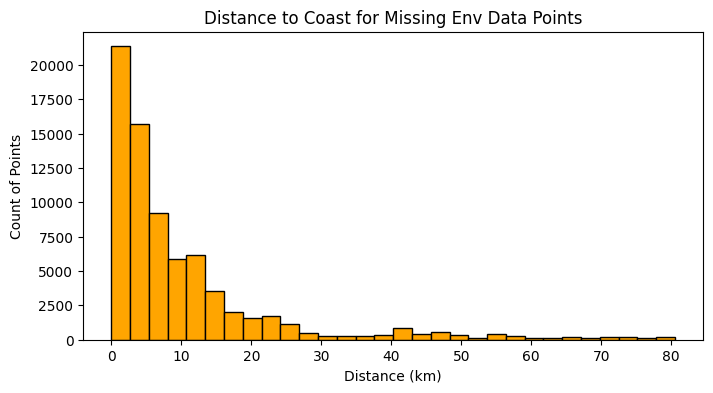

In [17]:
# Filtering for rows with missing weather data
missing_mask = df_copy["uo"].isna()
df_missing = df_copy[missing_mask].copy()

gdf_missing = gpd.GeoDataFrame(
    df_missing,
    geometry=gpd.points_from_xy(df_missing.LON, df_missing.LAT),
    crs="EPSG:4326",  # WGS84 (lat/lon)
)

# Clip the coastline to the bounding box of the missing points (+1 degree buffer) so the distance calc below doesn't have to consider coastline segments on the other side of the world
bounds = gdf_missing.total_bounds  # [minx, miny, maxx, maxy]
bbox_buffer = 1
gdf_coast_clipped = gdf_coast.cx[
    bounds[0] - bbox_buffer: bounds[2] + bbox_buffer,
    bounds[1] - bbox_buffer: bounds[3] + bbox_buffer,
]
if len(gdf_coast_clipped) == 0:
    # an empty clip would make every distance NaN below. Fall back to the full coastline rather than silently losing the coastal/deep-water split.
    print("no coastline segments in the buffered bounding box. using the full coastline.")
    gdf_coast_clipped = gdf_coast

# Project to meters before measuring distance - (EPSG:5070 works well for the Gulf of Mexico / USA)
target_crs = "EPSG:5070"
gdf_missing_meters = gdf_missing.to_crs(target_crs)
gdf_coast_meters = gdf_coast_clipped.to_crs(target_crs)

print("Merging coastline segments")
coast_union = gdf_coast_meters.geometry.union_all()  # .unary_union is deprecated

print(f"Calculating distance for {len(gdf_missing)} points")
gdf_missing["dist_to_coast_km"] = gdf_missing_meters.geometry.distance(coast_union) / 1000

print("\n Distance to coast for points with missing weather data ")
print(gdf_missing["dist_to_coast_km"].describe())

near_coast = (gdf_missing["dist_to_coast_km"] < 10).sum()
print(f"\nWithin 10km of coast: {near_coast} ({(near_coast / len(gdf_missing)) * 100:.1f}%)")

plt.figure(figsize=(8, 4))
plt.hist(gdf_missing["dist_to_coast_km"], bins=30, color="orange", edgecolor="black")
plt.title("Distance to Coast for Missing Env Data Points")
plt.xlabel("Distance (km)")
plt.ylabel("Count of Points")
plt.show()


### So most of the missing data is near the coast. These points are important to us. So we interpolate.

**Weather/ocean columns, for reference:**

- `uo` — Eastward seawater velocity (m/s, + = East)
- `vo` — Northward seawater velocity (m/s, + = North)
- `thetao` — Sea water potential temperature (°C)
- `swh` — Significant wave height (m): average height of the highest third of waves
- `mwd` — Mean wave direction (0–360°), the direction waves are coming *from*
- `wind_wave_height` — Height (m) of local wind-driven chop, excluding distant swell


In [18]:
from scipy.interpolate import NearestNDInterpolator

df_copy["dist_to_coast_km"] = np.nan
df_copy.loc[gdf_missing.index, "dist_to_coast_km"] = gdf_missing["dist_to_coast_km"]
print(f"Mapped distances for {len(gdf_missing)} rows.")

# Split the gaps into two parts
coastal_idx = df_copy[(df_copy["uo"].isna()) & (df_copy["dist_to_coast_km"] < 10)].index
deep_idx = df_copy[(df_copy["uo"].isna()) & (df_copy["dist_to_coast_km"] >= 10)].index

print(f"Deep-water gaps to fill (nearest-neighbor): {len(deep_idx)}")
print(f"Coastal/port gaps to zero out: {len(coastal_idx)}")

# Coastal- assume still water
cols_to_zero = ["uo", "vo", "swh", "wind_wave_height", "mwd"]
existing_zero_cols = [c for c in cols_to_zero if c in df_copy.columns]
df_copy.loc[coastal_idx, existing_zero_cols] = 0.0

# Deep water- nearest-neighbor interpolation from valid pings
if len(deep_idx) > 0:
    print("nearest values for deep-water gaps")
    target_cols = ["uo", "vo", "thetao", "swh", "mwd", "wind_wave_height"]

    valid_data = df_copy.dropna(subset=["uo"])
    if len(valid_data) > 200_000:
        valid_data = valid_data.sample(200_000, random_state=42)  # cap for memory

    points_valid = valid_data[["LON", "LAT"]].values
    points_missing =df_copy.loc[deep_idx, ["LON", "LAT"]].values

    for col in target_cols:
        print(f" Filling {col}")
        interpolator = NearestNDInterpolator(points_valid, valid_data[col].values)
        df_copy.loc[deep_idx, col] = interpolator(points_missing)

# Coastal temperature still needs a real value (0°C would be wrong)
if "thetao" in df_copy.columns:
    coastal_temp_nans = df_copy.loc[coastal_idx, "thetao"].isna()
    if coastal_temp_nans.any():
        print(" Interpolating temperature for coastal/port areas (avoiding 0°C)...")
        interpolator = NearestNDInterpolator(points_valid, valid_data["thetao"].values)
        fill_indices = df_copy.loc[coastal_idx][coastal_temp_nans].index
        fill_coords = df_copy.loc[fill_indices, ["LON", "LAT"]].values
        df_copy.loc[fill_indices, "thetao"] = interpolator(fill_coords)

print("All coastal/deep-water gaps filled.")


Mapped distances for 74282 rows.
Deep-water gaps to fill (nearest-neighbor): 24115
Coastal/port gaps to zero out: 50167
nearest values for deep-water gaps
 Filling uo
 Filling vo
 Filling thetao
 Filling swh
 Filling mwd
 Filling wind_wave_height
 Interpolating temperature for coastal/port areas (avoiding 0°C)...
All coastal/deep-water gaps filled.


In [19]:
df_copy.isnull().sum()

,0
BaseDateTime,0
LON,0
LAT,0
SOG,0
COG,0
Heading,0
IMO,0
Status,81
Length,0
Width,0


In [20]:
problem_cols = ["thetao", "swh", "mwd", "wind_wave_height"]

for col in problem_cols:
    missing_idx = df_copy[df_copy[col].isna()].index
    if len(missing_idx) == 0:
        print(f"  {col}: nothing left to fill.")
        continue

    valid_data = df_copy.dropna(subset=[col])
    if len(valid_data) > 100_000:
        valid_data = valid_data.sample(100_000, random_state=42)
    points_valid = valid_data[["LON", "LAT"]].values
    values_valid = valid_data[col].values

    try:
        interpolator = NearestNDInterpolator(points_valid, values_valid)
        points_missing = df_copy.loc[missing_idx, ["LON", "LAT"]].values
        df_copy.loc[missing_idx, col] = interpolator(points_missing)
        print(f"  Filled {col} successfully.")
    except Exception as e:
        print(f"  Failed to fill {col}: {e}")

print("\nFinal null check:")
print(df_copy[["uo", "vo", "thetao", "swh", "mwd"]].isna().sum())


  Filled thetao successfully.
  Filled swh successfully.
  Filled mwd successfully.
  Filled wind_wave_height successfully.

Final null check:
uo        0
vo        0
thetao    0
swh       0
mwd       0
dtype: int64


In [21]:
# Drop helper columns no longer needed downstream
df_final = df_copy.drop(columns=["dist_to_coast_km", "z", "depth"])
print(df_final.columns.tolist())


['BaseDateTime', 'LON', 'LAT', 'SOG', 'COG', 'Heading', 'IMO', 'Status', 'Length', 'Width', 'Draft', 'Cargo', 'drift_angle', 'uo', 'vo', 'thetao', 'swh', 'mwd', 'wind_wave_height']


## **Save final file**



In [22]:
output_file = "/content/drive/MyDrive/LCO2 Transport Project Final/cleaned_ais_copernicus_merged_dataset_2025.csv"

df_final.to_csv(output_file, index=False)
